In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/suraj520/customer-support-ticket-dataset/customer_support_tickets.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('/kaggle/input/datasets/suraj520/customer-support-ticket-dataset/customer_support_tickets.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (8469, 17)

Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [3]:
# Check ticket types and priority
print("Ticket Types:")
print(df['Ticket Type'].value_counts())

print("\nTicket Priority:")
print(df['Ticket Priority'].value_counts())

Ticket Types:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Ticket Priority:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


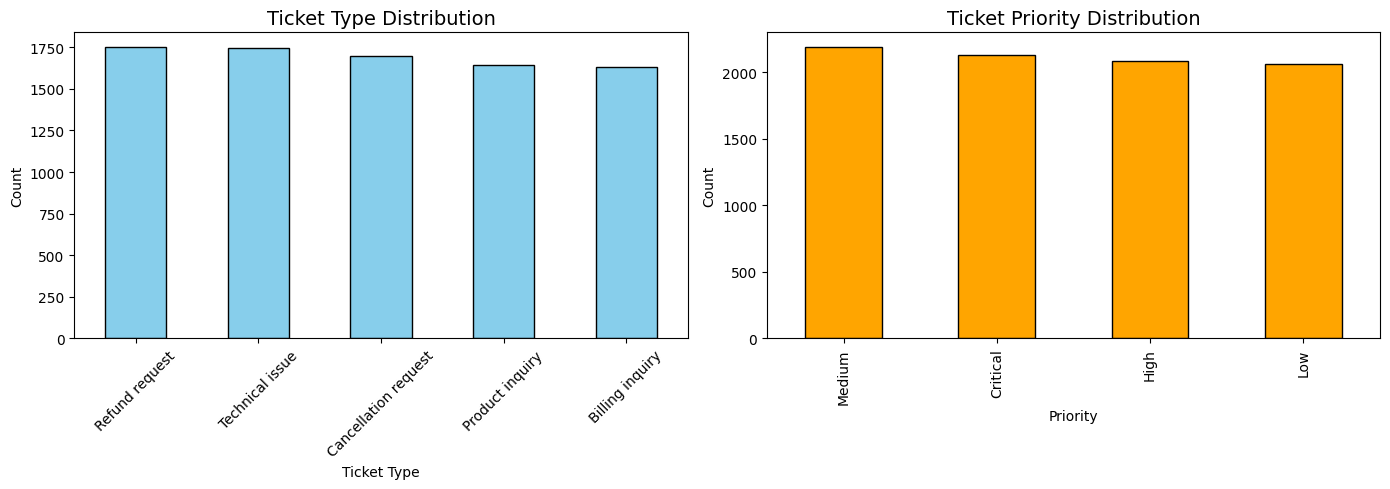

Graphs ready!


In [4]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ticket Type Chart
df['Ticket Type'].value_counts().plot(kind='bar', ax=axes[0], 
                                       color='skyblue', edgecolor='black')
axes[0].set_title('Ticket Type Distribution', fontsize=14)
axes[0].set_xlabel('Ticket Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Priority Chart
df['Ticket Priority'].value_counts().plot(kind='bar', ax=axes[1], 
                                           color='orange', edgecolor='black')
axes[1].set_title('Ticket Priority Distribution', fontsize=14)
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print("Graphs ready!")

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Prepare data
df['Ticket Description'] = df['Ticket Description'].fillna('')

X = df['Ticket Description']
y = df['Ticket Type']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# TF-IDF
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Predict
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 18.95%

Classification Report:
                      precision    recall  f1-score   support

     Billing inquiry       0.16      0.09      0.12       357
Cancellation request       0.16      0.17      0.16       327
     Product inquiry       0.18      0.19      0.19       316
      Refund request       0.21      0.25      0.23       345
     Technical issue       0.22      0.25      0.23       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.18      1694
        weighted avg       0.19      0.19      0.18      1694



In [6]:
from sklearn.linear_model import LogisticRegression

# Better model - Logistic Regression
model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train_tfidf, y_train)

y_pred2 = model2.predict(X_test_tfidf)
accuracy2 = accuracy_score(y_test, y_pred2)
print(f"Improved Model Accuracy: {accuracy2*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred2))

Improved Model Accuracy: 19.48%

Classification Report:
                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.14      0.16       357
Cancellation request       0.17      0.17      0.17       327
     Product inquiry       0.20      0.21      0.21       316
      Refund request       0.19      0.23      0.21       345
     Technical issue       0.22      0.23      0.23       349

            accuracy                           0.19      1694
           macro avg       0.19      0.20      0.19      1694
        weighted avg       0.19      0.19      0.19      1694



In [7]:
# Use Ticket Subject instead - better text
X = df['Ticket Subject'].fillna('')
y = df['Ticket Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

tfidf2 = TfidfVectorizer(max_features=500, stop_words='english')
X_train_tfidf2 = tfidf2.fit_transform(X_train)
X_test_tfidf2 = tfidf2.transform(X_test)

model3 = LogisticRegression(max_iter=1000)
model3.fit(X_train_tfidf2, y_train)

y_pred3 = model3.predict(X_test_tfidf2)
accuracy3 = accuracy_score(y_test, y_pred3)
print(f"Final Model Accuracy: {accuracy3*100:.2f}%")
print(classification_report(y_test, y_pred3))

Final Model Accuracy: 19.66%
                      precision    recall  f1-score   support

     Billing inquiry       0.23      0.07      0.11       357
Cancellation request       0.18      0.12      0.14       327
     Product inquiry       0.16      0.06      0.09       316
      Refund request       0.20      0.37      0.26       345
     Technical issue       0.20      0.35      0.25       349

            accuracy                           0.20      1694
           macro avg       0.19      0.19      0.17      1694
        weighted avg       0.20      0.20      0.17      1694



In [8]:
# Priority Tagging System
def assign_priority(ticket_type):
    if ticket_type in ['Technical issue', 'Refund request']:
        return 'High'
    elif ticket_type in ['Billing inquiry', 'Cancellation request']:
        return 'Medium'
    else:
        return 'Low'

df['Predicted_Priority'] = df['Ticket Type'].apply(assign_priority)

print("Priority Distribution:")
print(df['Predicted_Priority'].value_counts())

# Sample predictions
print("\nSample Ticket Classifications:")
sample = df[['Ticket Subject', 'Ticket Type', 'Predicted_Priority']].head(10)
print(sample)

Priority Distribution:
Predicted_Priority
High      3499
Medium    3329
Low       1641
Name: count, dtype: int64

Sample Ticket Classifications:
             Ticket Subject           Ticket Type Predicted_Priority
0             Product setup       Technical issue               High
1  Peripheral compatibility       Technical issue               High
2           Network problem       Technical issue               High
3            Account access       Billing inquiry             Medium
4                 Data loss       Billing inquiry             Medium
5             Payment issue  Cancellation request             Medium
6            Refund request       Product inquiry                Low
7              Battery life        Refund request               High
8      Installation support       Technical issue               High
9             Payment issue        Refund request               High


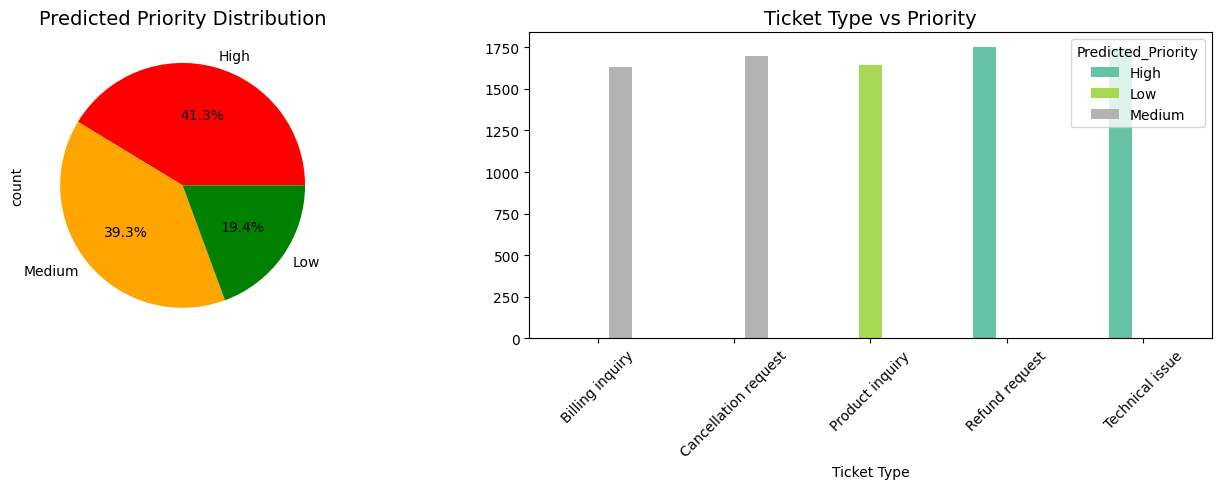

✅ Task 2 Complete!


In [9]:
# Final Summary Graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted Priority
df['Predicted_Priority'].value_counts().plot(kind='pie', 
    ax=axes[0], autopct='%1.1f%%', 
    colors=['red', 'orange', 'green'])
axes[0].set_title('Predicted Priority Distribution', fontsize=14)

# Ticket Type vs Priority
df.groupby(['Ticket Type', 'Predicted_Priority']).size().unstack().plot(
    kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Ticket Type vs Priority', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print("✅ Task 2 Complete!")